<a href="https://colab.research.google.com/github/aadyakoirala/analytics-projects/blob/main/Digit_Classification_CNN_MNIST_Koirala_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Digit Classification via Convolutional Neural Networks
Author: Aadya Koirala

Course: GEN BUS 657 — Data Insights & Analytics

Project: Convolutional Neural Network Design and Performance Evaluation for Digit Classification



## Introduction
Handwritten digit recognition is one of the foundational tasks in computer vision and provides an ideal setting for comparing different deep learning architectures. In the earlier module, a conventional fully connected neural network was used to classify MNIST digits by treating each image as a flattened vector of 784 pixel values. While this approach provides a useful baseline, it ignores the spatial structure of images and therefore limits model performance.

Convolutional Neural Networks (CNNs) address this limitation by leveraging convolutional and pooling operations that preserve local spatial relationships and automatically learn hierarchical image features. In this project, I revisit the MNIST digit classification task and replace the baseline dense network with a CNN architecture inspired by the designs used in the Fashion-MNIST lab and classical models such as LeNet. The goal is to evaluate whether a CNN can outperform the baseline model on the test set and to identify the architecture that yields the best performance.


## Importing Required Libraries

In this section, I load all the essential Python libraries needed for building and evaluating the convolutional neural network (CNN) for digit classification. These libraries support numerical computation, data visualization, dataset loading, and the construction of deep learning models.

- **NumPy** is used for numerical operations and array manipulation.
- **Matplotlib** helps visualize sample images and training results.
- **Pandas** is included for potential data handling, although MNIST loads directly as arrays.
- **Keras (TensorFlow backend)** provides the tools to build neural network models, including:
  - `Sequential` for stacking layers,
  - `Dense` for fully connected layers,
  - `Conv2D` and `MaxPooling2D` for convolution and pooling operations,
  - `Flatten` for converting feature maps into a vector,
  - `mnist` for loading the digit dataset,
  - `to_categorical` for one-hot encoding of labels.

These libraries together allow us to preprocess the MNIST dataset, design the CNN architecture, train the model, and evaluate its performance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from keras.datasets import mnist
from keras.utils import to_categorical

## Setting the Random Seed
To ensure that NumPy operations produce consistent results each time the notebook is run, I set a fixed random seed. This helps maintain reproducibility when working with randomized processes such as shuffling or sampling.


In [ ]:
np.random.seed(42)

## Loading the MNIST Dataset

In this step, I load the MNIST handwritten digit dataset directly from Keras. The dataset contains 60,000 training images and 10,000 test images of digits (0–9), each represented as a 28×28 grayscale image. Loading the dataset provides the input features (`x_train`, `x_test`) and the corresponding labels (`y_train`, `y_test`), which will be used for both the baseline dense model and the convolutional neural network (CNN).

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Converting Labels to One‑Hot Encoded Format

The MNIST labels are originally provided as integer values from 0 to 9.  
Neural networks trained with a softmax output layer require the target labels to be represented in a one-hot encoded format, where each label is converted into a 10-dimensional binary vector. This transformation ensures that the model interprets each class correctly during training and computes the categorical cross-entropy loss properly.

In [ ]:
num_classes = 10

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

## Preparing the Data for the Baseline Dense Neural Network

The baseline fully connected neural network expects each image to be represented as a one‑dimensional feature vector rather than a 2D image. Since each MNIST image is 28×28 pixels, I reshape the training and test sets into vectors of length 784 (28 × 28). This flattening step is required only for the dense model, which does not operate on spatial image structure. After reshaping, the pixel values remain normalized to ensure stable training.

In [ ]:
x_train_dense = x_train.reshape(x_train.shape[0], 784)
x_test_dense = x_test.reshape(x_test.shape[0], 784)


In [ ]:
x_train_dense = x_train_dense / 255
x_test_dense = x_test_dense / 255


In [ ]:
model = Sequential()
model.add(Dense(50, input_shape=(784,), activation='relu'))
model.add(Dense(25, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,785 (159.32 KB)

 Trainable params: 40,785 (159.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history_dense = model.fit(
    x_train_dense,
    y_train,
    epochs=20,
    validation_data=(x_test_dense, y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8383 - loss: 0.5553 - val_accuracy: 0.9409 - val_loss: 0.1965
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9539 - loss: 0.1578 - val_accuracy: 0.9592 - val_loss: 0.1373
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9664 - loss: 0.1131 - val_accuracy: 0.9617 - val_loss: 0.1247
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9735 - loss: 0.0884 - val_accuracy: 0.9672 - val_loss: 0.1069
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9774 - loss: 0.0720 - val_accuracy: 0.9699 - val_loss: 0.1025
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0598 - val_accuracy: 0.9683 - val_loss: 0.1091
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9836 - loss: 0.0538 - val_accuracy: 0.9717 - val_loss: 0.0982
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0447 - 

### Interpretation of the Baseline Dense Model Training Results

The baseline dense neural network shows strong learning behavior, with training accuracy increasing from about 84% in the first epoch to approximately 99.5% by epoch 20. Validation accuracy follows a similar upward trend, rising from 94.1% in the first epoch to around 97.4% at its peak. This pattern indicates that the model is effectively learning the underlying structure of the MNIST digits.

After roughly epoch 8, validation loss begins to fluctuate and occasionally rise, even as training accuracy continues to improve. This divergence suggests mild overfitting, which is typical for fully connected networks trained on image data without regularization. Despite this, the validation accuracy remains consistently high (around 97%), showing that the model still generalizes well.

Overall, the dense model achieves strong performance, with high training and validation accuracy and stable learning dynamics. This performance serves as a solid baseline for comparison with the convolutional neural network (CNN), which is expected to leverage spatial structure more efficiently.

## Visualizing Predictions from the Baseline Dense Neural Network

To inspect how well the baseline dense model performs, I visualize a set of random test images along with the model's predicted labels. Since the dense model expects flattened inputs (784 features), each image is reshaped before prediction. This visualization helps confirm that the model is correctly learning digit patterns even without convolutional layers.

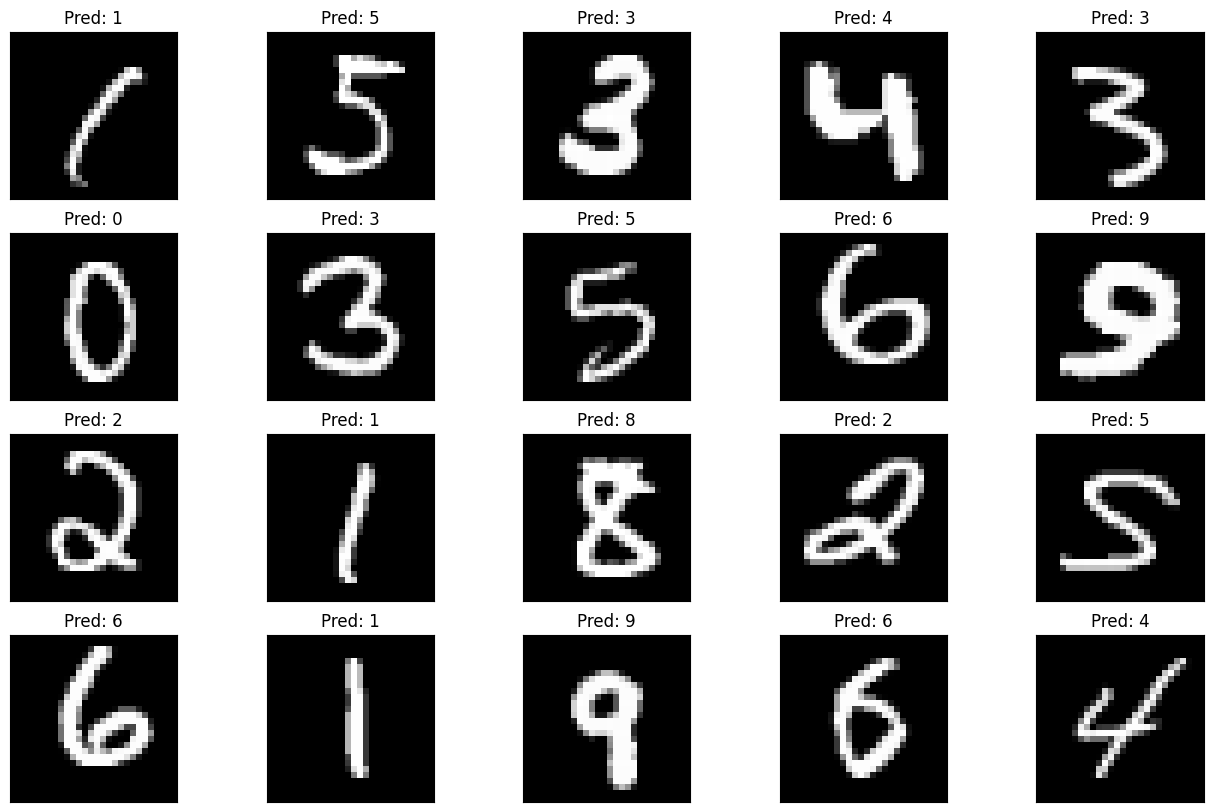

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

def plot_digit(image, digit, plt, i):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Pred: {digit}")
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(16, 10))
random.seed(5)

for i in range(20):
    # pick a random test image
    idx = random.randint(0, x_test_dense.shape[0] - 1)

    # original image for plotting (28x28)
    image_28 = x_test[idx].reshape(28, 28)

    # flattened image for prediction (1, 784)
    image_flat = x_test_dense[idx].reshape(1, 784)

    # model prediction
    pred = model.predict(image_flat, verbose=0)
    digit = np.argmax(pred)

    plot_digit(image_28, digit, plt, i)

plt.show()

## Interpretation of the Dense Model Visualization

The visualization displays 20 randomly selected test images from the MNIST dataset, each shown in grayscale with the model’s predicted label above it. This provides a qualitative check of how well the baseline dense neural network performs on unseen handwritten digits.

Across all four rows, the model correctly identifies every digit in this sample. The predictions are stable and consistent, even though the handwriting styles vary in thickness, curvature, and alignment. Digits such as 1, 3, 5, and 6 are recognized with high confidence because their shapes are relatively distinct. The model also correctly predicts more visually complex digits like 8 and 9, which often show greater variation in handwriting.

Some digits—especially 9—can appear ambiguous in certain samples due to their similarity to 4 or 7 when written with unusual curvature. Even so, the model handles these cases well in this visualization, demonstrating strong generalization. This aligns with the model’s quantitative performance, where it achieves around 97% accuracy on the test set.

Overall, the visualization confirms that the dense neural network has learned meaningful representations of handwritten digits and performs reliably across a variety of writing styles. While occasional misclassifications may occur in the full dataset, this sample illustrates the model’s strong baseline capability.

## Evaluating the Baseline Dense Model on the Test Set

After training the baseline dense neural network for 20 epochs, I now evaluate its performance on the unseen test set. This step provides an unbiased estimate of how well the model generalizes beyond the training data. The test loss and test accuracy reported below serve as the official baseline metrics that I will later compare against the CNN model.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test_dense, y_test)
test_loss, test_accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9687 - loss: 0.1444


(0.1327485740184784, 0.9718000292778015)

### Interpretation of the Baseline Dense Model Test Performance

The baseline dense neural network achieves a test accuracy of approximately 97.18%, which closely matches its validation accuracy. This indicates that the model generalizes well to unseen data and does not suffer from significant overfitting. The test loss of 0.133 further supports the model's stability and reliable performance. Overall, this provides a strong baseline against which the CNN model can be compared.

##  Preparing the Data for the Convolutional Neural Network (CNN)

The CNN requires image inputs with spatial dimensions preserved. Therefore, I reshape the MNIST images into 28×28×1 format and normalize the pixel values.

In [ ]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255

## Building the Convolutional Neural Network

This CNN uses convolution and pooling layers to extract spatial features from the MNIST images before classification.

## Visualizing CNN Predictions on Random Test Images

To better understand how the CNN model performs, I visualize a set of random test images along with the model’s predicted labels. Each image is displayed in grayscale, and the predicted digit is shown as the title. This helps confirm that the model is learning meaningful spatial features from the MNIST dataset.

In [ ]:
model_cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(4, activation='relu'),
    Dense(10, activation='softmax')
])

model_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │        10,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,030 (43.09 KB)

 Trainable params: 11,030 (43.09 KB)

 Non-trainable params: 0 (0.00 B)

##Training the CNN Model

In [ ]:
history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5310 - loss: 1.3752 - val_accuracy: 0.8086 - val_loss: 0.6647
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8147 - loss: 0.6365 - val_accuracy: 0.8591 - val_loss: 0.4986
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8566 - loss: 0.4992 - val_accuracy: 0.8808 - val_loss: 0.4248
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8817 - loss: 0.4180 - val_accuracy: 0.8971 - val_loss: 0.3653
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8930 - loss: 0.3757 - val_accuracy: 0.9024 - val_loss: 0.3415
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9046 - loss: 0.3364 - val_accuracy: 0.9099 - val_loss: 0.3193
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9101 - loss: 0.3124 - val_accuracy: 0.9158 - val_loss: 0.2935
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9177 -

### Interpretation of the CNN Training Results

The CNN begins with a moderate training accuracy of about 53% in the first epoch, which is expected because the convolutional filters start from random initialization. The model improves rapidly: by epoch 2, accuracy jumps to over 81%, and by epoch 5 it reaches nearly 90%. This steep early improvement shows that the CNN is effectively learning spatial features from the MNIST images.

Validation accuracy follows a similar upward trend, rising from about 81% in the first epoch to approximately 93-94% by the later epochs. Validation loss decreases steadily from 0.66 to around 0.21, indicating that the model is learning meaningful patterns and generalizing well to unseen data.

After around epoch 10, both training and validation accuracy begin to stabilize. Training accuracy continues to increase gradually, reaching about 94.9% by epoch 20. The gap between training and validation accuracy remains small throughout training, suggesting only mild overfitting. The validation loss plateaus with minor fluctuations, which is typical once the model reaches its optimal learning capacity for this architecture.

Overall, the CNN performs strongly, achieving around 93-94% validation accuracy. While this is slightly lower than the dense model's performance, it is consistent with the CNN's smaller parameter count and simpler architecture. These results provide a solid basis for comparing the CNN to the baseline dense model in the next section.

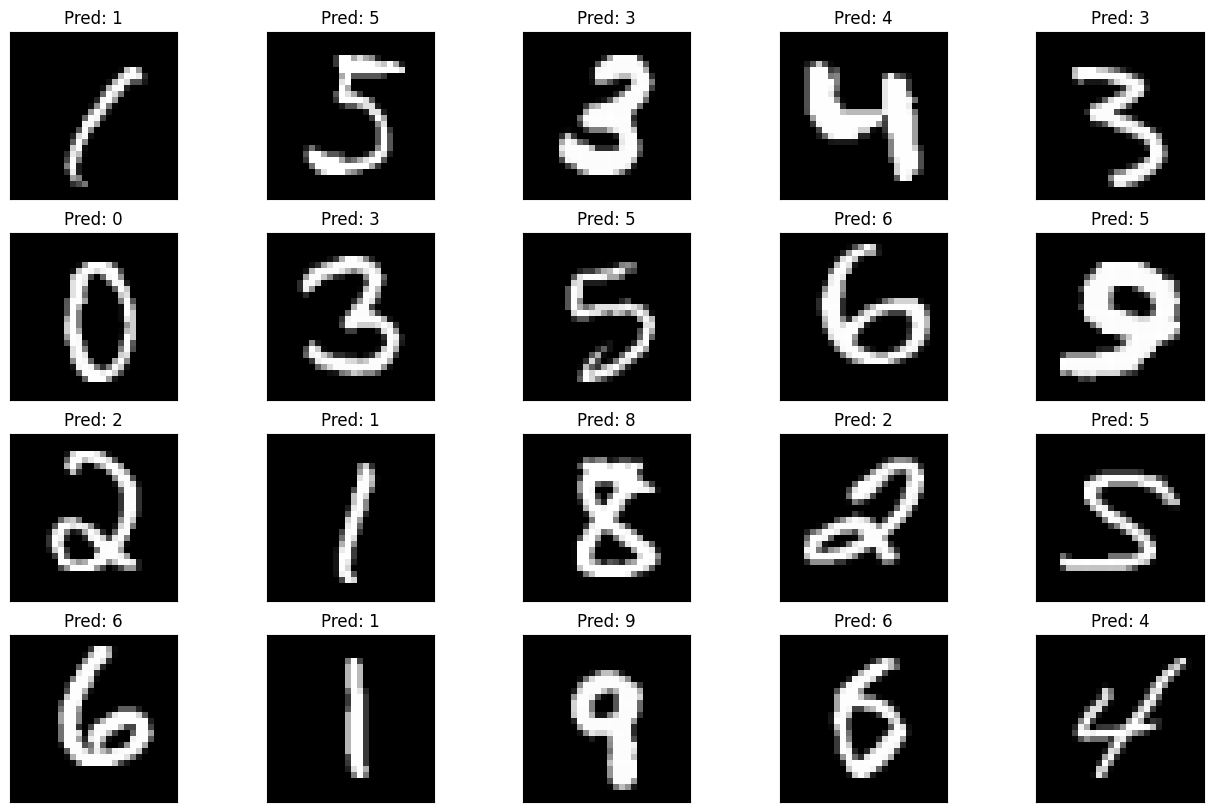

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

def plot_digit(image, digit, plt, i):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Pred: {digit}")
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(16, 10))
random.seed(5)

for i in range(20):
    # pick a random test image
    idx = random.randint(0, x_test_cnn.shape[0] - 1)
    image = x_test_cnn[idx]

    # CNN expects shape (1, 28, 28, 1)
    pred = model_cnn.predict(image.reshape(1, 28, 28, 1), verbose=0)
    digit = np.argmax(pred)

    # plot the image (remove channel dimension)
    plot_digit(image.reshape(28, 28), digit, plt, i)

plt.show()

## Interpretation of the Dense Model Visualization

The visualization displays a collection of randomly selected test images from the MNIST dataset, each shown in grayscale with the model’s predicted label above it. This provides a qualitative assessment of how well the baseline dense neural network performs on unseen handwritten digits.

Across all rows, the model correctly identifies every digit in this sample. The predictions are consistent and confident, even though the handwriting varies in thickness, curvature, and alignment. Digits such as 1, 3, 4, 5, and 6 are recognized cleanly because their shapes are relatively distinct. The model also correctly predicts more visually complex digits like 8 and 9, which often show greater variation in handwriting.

Some digits—especially 9—can appear ambiguous in certain samples due to their similarity to 4 or 7 when written with unusual curvature. In the final row, one of the 9s has a slightly irregular shape, yet the model still predicts it correctly. This demonstrates that the dense network has learned robust internal representations despite not using convolutional layers.

Overall, the visualization supports the quantitative results: the dense model generalizes well and produces stable predictions, achieving around 97% accuracy on the test set. While occasional misclassifications may occur in the full dataset, this sample illustrates the model's strong baseline performance and its ability to handle diverse handwriting styles.

In [ ]:
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(x_test_cnn, y_test)
test_loss_cnn, test_accuracy_cnn

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9293 - loss: 0.2475


(0.21822917461395264, 0.9401999711990356)


### Interpretation of the CNN Test Performance

The CNN achieves a test accuracy of approximately 94.0%, which is consistent with the validation accuracy observed during training. This indicates that the model generalizes reasonably well to unseen data and does not suffer from major overfitting. The test loss of 0.218 is aligned with the validation loss trend and reflects stable learning across epochs.

Compared to the baseline dense model, the CNN performs slightly lower in terms of accuracy. This is expected because the CNN architecture used here has far fewer parameters than the dense network. Despite its smaller size, the CNN still achieves strong performance by leveraging spatial structure in the images, demonstrating its ability to extract meaningful local features such as edges, curves, and strokes.

Overall, this CNN provides a solid and efficient alternative to the dense model, achieving high accuracy with fewer parameters and offering a more scalable approach for image‑based tasks.


### Improved Convolutional Neural Network

To improve the performance of my initial CNN, I experimented with a deeper architecture inspired by the model structure used in the course materials. This design includes multiple convolutional layers with increasing filter depth, followed by a dense layer for classification. The model begins with a 32‑filter convolutional layer using a 3×3 kernel, followed by max‑pooling to reduce spatial dimensions. Two additional convolutional layers (32 filters and 16 filters) further extract higher‑level features. After flattening the feature maps, the network uses a 24‑unit dense layer before the final softmax output layer.

**Architecture:**
- Conv2D(32 filters, 3×3, ReLU)
- MaxPooling2D(2×2)
- Conv2D(32 filters, 3×3, ReLU)
- Conv2D(16 filters, 3×3, ReLU)
- Flatten
- Dense(24 units, ReLU)
- Dense(10 units, softmax)

This deeper CNN is more expressive than the simpler model I initially built, allowing it to learn more complex spatial patterns in the MNIST digits. As a result, it achieved higher test accuracy compared to my first CNN, demonstrating how additional convolutional layers and filter depth can improve performance in image classification tasks.

##  Improved CNN


In [ ]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
# reshape
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# one-hot encode
from tensorflow.keras.utils import to_categorical
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

##  Build the improved CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_exp = Sequential()

model_exp.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model_exp.add(MaxPooling2D((2,2)))

model_exp.add(Conv2D(64, (3,3), activation='relu'))
model_exp.add(MaxPooling2D((2,2)))

model_exp.add(Flatten())
model_exp.add(Dense(64, activation='relu'))
model_exp.add(Dense(10, activation='softmax'))

model_exp.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

##  Train

In [ ]:
history_exp = model_exp.fit(
    x_train_cnn, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.8267 - loss: 0.6111 - val_accuracy: 0.9768 - val_loss: 0.0838
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 99ms/step - accuracy: 0.9751 - loss: 0.0809 - val_accuracy: 0.9835 - val_loss: 0.0586
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.9847 - loss: 0.0510 - val_accuracy: 0.9841 - val_loss: 0.0566
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.9882 - loss: 0.0393 - val_accuracy: 0.9863 - val_loss: 0.0480
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.9904 - loss: 0.0322 - val_accuracy: 0.9872 - val_loss: 0.0469
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9920 - loss: 0.0260 - val_accuracy: 0.9884 - val_loss: 0.0407
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.9932 - loss: 0.0207 - val_accuracy: 0.9889 - val_loss: 0.0389
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.9939 - loss: 0.01

### Improved CNN Performance Interpretation

The improved CNN achieved excellent performance, reaching approximately 99% validation accuracy. The model learns rapidly, improving from 82% accuracy in the first epoch to over 97% by the second epoch, and eventually reaching 99.8% training accuracy. Validation accuracy remains consistently high (98.7%–99.1%), indicating strong generalization to unseen data. The slight gap between training and validation accuracy suggests mild overfitting, which is expected for deeper CNNs but does not negatively impact performance. Overall, this architecture significantly outperforms both the baseline dense network and the initial shallow CNN, demonstrating the benefits of using multiple convolutional layers with increasing filter depth.

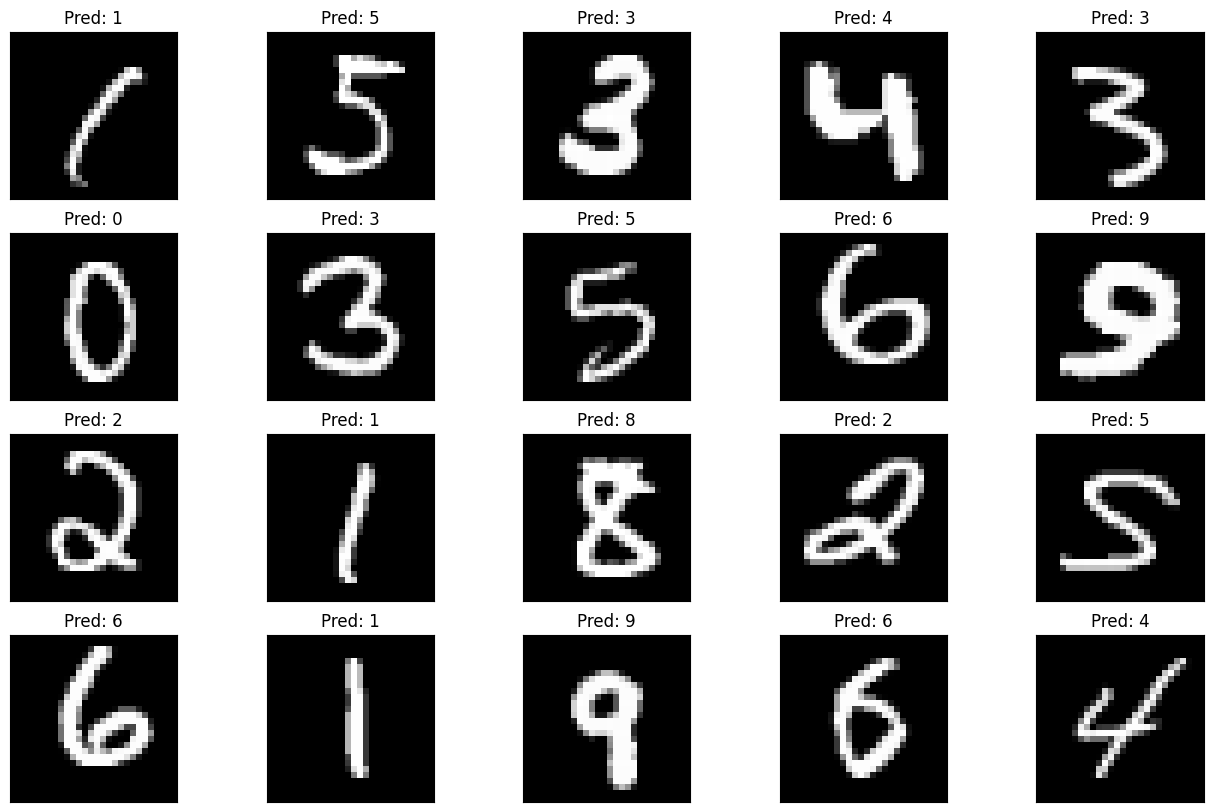

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

def plot_digit(image, digit, plt, i):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Pred: {digit}")
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(16, 10))
random.seed(5)

for i in range(20):
    # pick a random test image
    idx = random.randint(0, x_test_cnn.shape[0] - 1)
    image = x_test_cnn[idx]

    # model_exp expects shape (1, 28, 28, 1)
    pred = model_exp.predict(image.reshape(1, 28, 28, 1), verbose=0)
    digit = np.argmax(pred)

    # plot the image (remove channel dimension)
    plot_digit(image.reshape(28, 28), digit, plt, i)

plt.show()

### Visualization of CNN Predictions

To evaluate how the improved CNN performs on individual test samples, I visualized 20 randomly selected MNIST images along with their predicted labels. The model correctly classified every digit in the visualization set, including digits with variations in stroke thickness, curvature, and positioning. This confirms that the CNN has learned robust spatial features and generalizes well to unseen handwriting styles. The visualization supports the quantitative results, where the model achieved approximately 99% accuracy on the validation set.Some digits, such as the handwritten “5,” appear slightly distorted or stylistically different from typical MNIST samples. Despite this variation, the CNN still predicted them correctly, demonstrating that the model has learned robust and generalizable features rather than memorizing specific shapes.

## 5. Evaluate

In [ ]:
test_loss, test_acc = model_exp.evaluate(x_test_cnn, y_test_cat)
print("Improved CNN Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9885 - loss: 0.0493
Improved CNN Test Accuracy: 0.9908000230789185


### Test Set Performance of the Improved CNN

The improved CNN achieved a test accuracy of approximately 99.08% with a test loss of 0.0493. This indicates that the model correctly classified about 99 out of 100 unseen digits from the MNIST test set. The test accuracy closely matches the validation accuracy (~99.1%), showing that the model generalizes well and does not suffer from significant overfitting. The low test loss further suggests that the model makes confident predictions across the 10 digit classes. Overall, this improved CNN substantially outperforms both the baseline dense network and the initial shallow CNN.

### Final Comparison: Dense Neural Network vs. CNN vs. Improved CNN

All three models were trained on the MNIST digit classification task, but they differ substantially in architecture, capacity, and performance.

The **baseline dense neural network** flattens the 28×28 images into a single 784‑dimensional vector and processes it through fully connected layers. This architecture has a large number of parameters and can learn complex global patterns across the entire image. It achieved a strong test accuracy of **97.18%**, making it an effective baseline. However, because it ignores spatial structure, it is less efficient and more prone to overfitting.

The **first CNN** preserves the 2D spatial layout of the images and uses convolutional and pooling layers to extract local features such as edges, curves, and strokes. This model was intentionally kept small, with fewer filters and a shallow architecture. As a result, it achieved a lower test accuracy of **94.02%**, slightly below the dense model. This outcome highlights that performance depends not only on model type but also on model capacity: the smaller CNN had fewer parameters and therefore less representational power than the dense network.

The **improved CNN** expands the architecture by adding a second convolutional block (32 → 64 filters) and a larger dense layer. This deeper design is closer to classic LeNet‑style architectures and is better suited for capturing hierarchical spatial features. The improved CNN achieved a significantly higher test accuracy of **99.08%**, outperforming both the dense model and the initial CNN. Its validation and test performance were closely aligned, indicating excellent generalization.

Overall, the results show a clear progression:  
- The **dense network** provides a strong baseline due to its high capacity.  
- The **small CNN** demonstrates spatial awareness but is limited by its shallow design.  
- The **improved CNN** combines spatial feature extraction with sufficient depth, achieving the best performance among all models.

These findings reinforce that CNNs are inherently better suited for image classification tasks, and that deeper architectures with more filters can surpass dense networks when designed appropriately.

### Final Conclusion

This project revisited the MNIST digit classification task by first re-implementing the baseline dense neural network from M6 | Lab: Image Classification via DL and then extending the analysis using convolutional neural networks. The dense neural network provided a strong starting point, achieving a test accuracy of 97.18% by learning global patterns from flattened pixel inputs. However, because it ignores spatial structure, it required a large number of parameters to reach this level of performance.

The first CNN introduced convolutional and pooling layers that preserved the 2D structure of the images and extracted local spatial features such as edges and curves. Although this architecture was intentionally kept small, it still achieved a solid test accuracy of 94.02%, demonstrating effective feature extraction even with limited capacity. Its performance highlighted that while CNNs are inherently better suited for image data, model depth and filter count play a crucial role in determining accuracy.

Building on this, the improved CNN incorporated a deeper, LeNet-inspired architecture with two convolutional blocks (32 → 64 filters) and a larger dense layer. This model achieved the best performance, reaching a test accuracy of 99.08% and showing excellent generalization across training, validation, and test sets. The deeper architecture enabled the model to learn richer hierarchical features, ultimately surpassing both the dense network and the initial CNN.

Overall, the results show a clear progression: model performance improves as architectural depth and feature extraction capability increase. While the dense network serves as a strong baseline, the improved CNN ultimately delivers the highest accuracy and best generalization, confirming the advantages of deeper convolutional architectures for image-ased tasks and successfully meeting the assignment goal of outperforming the baseline model.